## Predict dynamics with our model:
1. For wav or mp3 audio on your own device:<br>
`!python pytorch/inference.py --ckpt /path/model.ckpt --infer_audio /path/audio.wav`
2. Also, we can try the h5 files from our pre-proc dataset:<br>
`!python pytorch/inference.py --ckpt /path/model.ckpt --infer_h5 /path/input.h5`

## How to add dynamic markings into a music score
1) Use the “high-resolution piano transcription” in `workspaces/AMT/HPT` to transcribe audio to MIDI, then convert the MIDI to sheet music (ignore MIDI velocity; it will not be mapped to dynamics).
2) Alternatively, use a score-level AMT system to transcribe audio directly to sheet music. Current score-level AMT systems do not provide dynamic markings; our method fills this gap.
3) Apply our model-predicted dynamic markings to the transcribed sheet music.

In [1]:
!python pytorch/inference.py\
 --ckpt "./workspaces/checkpoints/formal latent8 mmoe8 5x5-sone-MultiTaskCNN-['dynamic', 'change_point', 'beat', 'downbeat']-fold0/epoch_96_valf1_0.53453.pth"\
 --infer_h5 "../202509_bark_data/workspaces/hdf5s/mazurka_sr22050/mazurka06-1/pid9054-01.h5"
 

Files epoch_96_valf1_0.53453.pth: 100%|███████████| 1/1 [00:08<00:00,  8.63s/it]
[epoch_96_valf1_0.53453.pth] -> /media/datadisk/home/22828187/zhanh/2025_achieve/202509_icassp/piano-dynamic-estimation/workspaces/checkpoints/outputs/formal latent8 mmoe8 5x5-sone-MultiTaskCNN-['dynamic', 'change_point', 'beat', 'downbeat']-fold0/epoch_96_valf1_0.53453/pid9054-01.h5


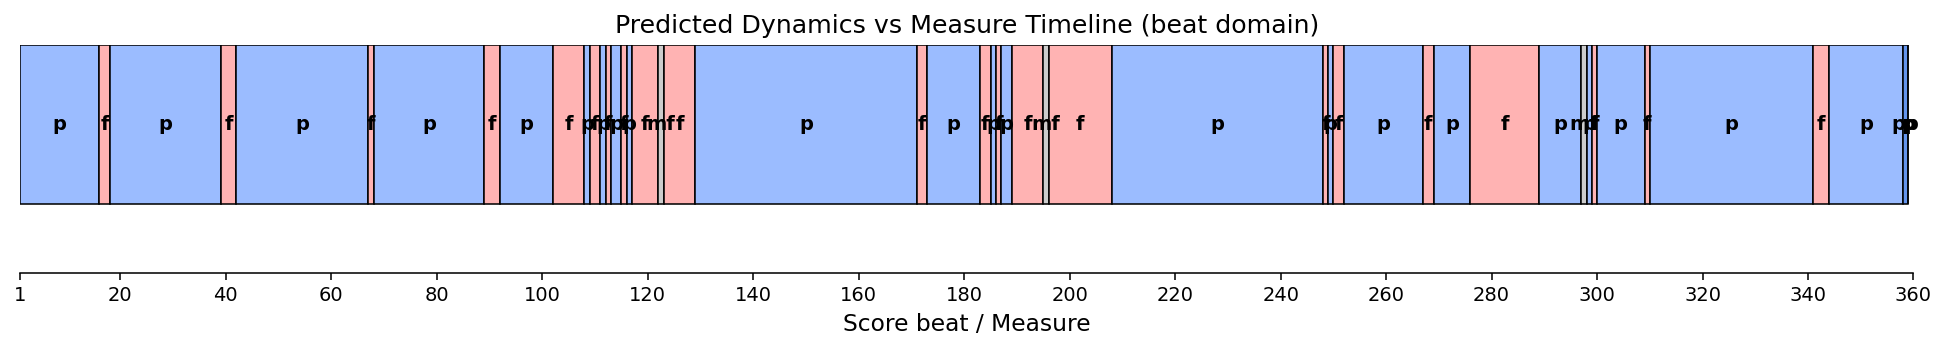

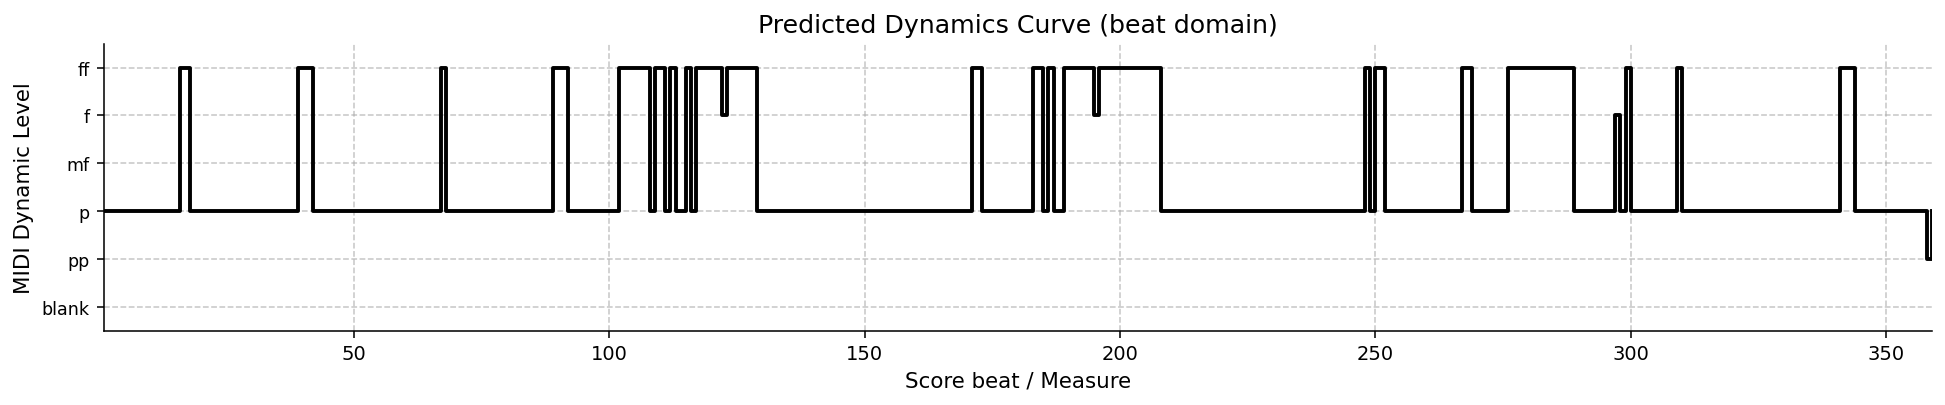

In [ ]:
import sys, os
ROOT = "/media/datadisk/home/22828187/zhanh/2025_achieve/202509_icassp/piano-dynamic-estimation"
PT   = os.path.join(ROOT, "pytorch")
for p in (ROOT, PT):
    if p not in sys.path:
        sys.path.insert(0, p)

from pytorch.utils import plot_predicted_dynamics_h5

out_h5 = "./workspaces/checkpoints/outputs/formal latent8 mmoe8 5x5-sone-MultiTaskCNN-['dynamic', 'change_point', 'beat', 'downbeat']-fold0/epoch_96_valf1_0.53453/pid9054-01.h5"
plot_predicted_dynamics_h5(out_h5)
